# FKPT neutrino-kernel test: 8 permutations

This notebook tests the current **single-public-flag** neutrino implementation at the low-level FKPT table layer.

It computes all combinations

```python
MU0_VALUES = [0.0, -0.5]
INCLUDE_NEUTRINO_CORRECTIONS = [False, True]
BEYOND_EDS = [False, True]
```

For each multipole \(\ell=0,2,4\), all 8 results are shown in one panel.

Important updates relative to the older notebook:

1. It no longer relies on the refactored `fkptjax.rsd/pipelines` multipole projector.
   Instead, it uses the legacy FOLPS route directly:
   \[
   {\tt table} \rightarrow P(k,\mu) \rightarrow P_\ell(k).
   \]
   This mirrors the old desilike projection logic.

2. The low-level FKPT call still has only the **internal** object
   `neutrino_correction=None/object`. There is no low-level
   `include_neutrino_corrections` keyword.

3. The input linear spectrum mirrors the public `full_shape.py` behavior:
   - neutrino correction off: use total matter \(P_m\);
   - neutrino correction on: use \(P_{cb}\) and \(\mu_\nu=\delta_{\rm tot}/\delta_{cb}\).

The public desilike option remains only:

```yaml
include_neutrino_corrections: true
```


In [1]:
# Environment and imports

import os
import sys
import time
from pathlib import Path

os.environ.setdefault("FOLPS_BACKEND", "jax")
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import numpy as np
np.int = int  # ISiTGR compatibility with recent NumPy

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

cwd = Path.cwd().resolve()

# Add your local editable fkptjax checkout if needed.
candidate_srcs = []
if os.environ.get("FKPTJAX_SRC"):
    candidate_srcs.append(Path(os.environ["FKPTJAX_SRC"]).expanduser().resolve())
candidate_srcs += [
    cwd / "src",
    cwd.parent / "src",
    Path.home() / "FS_DR2" / "src" / "fkptjax_muMG" / "src",
]

for src in candidate_srcs:
    if (src / "fkptjax").exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src))
        print(f"Added to sys.path: {src}")
        break

from cosmoprimo.fiducial import DESI
from fkptjax.neutrinos import NeutrinoTransferCorrection
from fkptjax.rsd import pack_fkpt_bias
from fkptjax.kfuncs_to_tables import Kfuncs_to_tables

import folps as folpsv2

print("cwd:", cwd)
print("python:", sys.executable)
print("jax:", jax.__version__)
print("devices:", jax.devices())


Added to sys.path: /global/u2/c/crisjagq/FS_DR2/src/fkptjax_muMG/src
⚠️ No GPU found. Using JAX with CPU.
cwd: /global/u2/c/crisjagq/FS_DR2/src/fkptjax_muMG/examples
python: /global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/bin/python
jax: 0.9.1
devices: [CpuDevice(id=0)]


In [2]:
# Configuration

ZOUT = 0.706
MNU = 0.10
N_UR = 2.0308
N_NCDM = 1

KMIN_LIN = 1.0e-3
KMAX_LIN = 1.0
KMIN_PLOT = 0.02
KMAX_PLOT = 0.20

XNOW = -3.912023  # ln(a_init), so z_init is about 49

# Use -0.5 because this is the sign used in the synthetic benchmark.
# Change to +0.3 if you specifically want the enhanced-gravity case.
MU0_VALUES = [0.0, -0.5]

INCLUDE_NEUTRINO_CORRECTIONS = [False, True]
BEYOND_EDS = [False, True]

ELLS = (0, 2, 4)

# Modest settings for a diagnostic. Increase for validation-quality curves.
NK_KERNEL = 100
NQUAD_STEPS = 220
NQ = 10
NR = 10
NMU = 8

assert isinstance(BEYOND_EDS, list)
assert len(MU0_VALUES) * len(INCLUDE_NEUTRINO_CORRECTIONS) * len(BEYOND_EDS) == 8


In [3]:
# Cosmology, linear spectra, and internal neutrino-correction helper

def make_mu_grid(nmu):
    x, w = np.polynomial.legendre.leggauss(nmu)
    return jnp.asarray(0.5 * (x + 1.0)), jnp.asarray(0.5 * w)


def legendre_even(ell, mu):
    """Even Legendre polynomials needed for ell=0,2,4."""
    mu = jnp.asarray(mu)
    if ell == 0:
        return jnp.ones_like(mu)
    if ell == 2:
        return 0.5 * (3.0 * mu**2 - 1.0)
    if ell == 4:
        return (35.0 * mu**4 - 30.0 * mu**2 + 3.0) / 8.0
    raise ValueError(f"Unsupported ell={ell}; expected 0, 2, or 4.")


def project_even_multipoles(pkmu, mu, wmu, ells=ELLS):
    """Legacy-style even multipole projection over mu in [0, 1]."""
    pkmu = jnp.asarray(pkmu)
    mu = jnp.asarray(mu)
    wmu = jnp.asarray(wmu)
    return jnp.stack([
        (2 * ell + 1) * jnp.sum(wmu[None, :] * legendre_even(ell, mu)[None, :] * pkmu, axis=-1)
        for ell in ells
    ])


def smooth_now_savgol(k, pk, window=41, polyorder=3):
    """Simple no-wiggle proxy for a controlled standalone FKPT test."""
    k = np.asarray(k, dtype=float)
    pk = np.asarray(pk, dtype=float)

    window = min(int(window), len(k) - 1 if (len(k) - 1) % 2 else len(k) - 2)
    window = max(window, polyorder + 3)
    if window % 2 == 0:
        window += 1

    return np.exp(
        savgol_filter(np.log(pk), window_length=window, polyorder=polyorder)
    )


def _fourier_table_of(fourier, of):
    """Robust helper across cosmoprimo versions."""
    if of == "delta_m":
        try:
            return fourier.table(non_linear=False, of="delta_m")
        except Exception:
            # cosmoprimo default is usually total matter.
            return fourier.table(non_linear=False)
    return fourier.table(non_linear=False, of=of)


def _extract_pk_at_z(k_all, z_all, pk_all, z_target):
    """Return P(k,z_target), accepting both (nk,nz) and (nz,nk) table layouts."""
    k_all = np.ravel(np.asarray(k_all, dtype=float))
    z_all = np.ravel(np.asarray(z_all, dtype=float))
    pk_all = np.asarray(pk_all, dtype=float)

    if pk_all.shape == (k_all.size, z_all.size):
        pk = pk_all
    elif pk_all.shape == (z_all.size, k_all.size):
        pk = pk_all.T
    else:
        raise ValueError(
            f"Unexpected P(k,z) table shape {pk_all.shape}; "
            f"expected {(k_all.size, z_all.size)} or {(z_all.size, k_all.size)}."
        )

    order_z = np.argsort(z_all)
    z_all = z_all[order_z]
    pk = pk[:, order_z]

    if z_all.size == 1:
        out = pk[:, 0]
    else:
        out = np.array([np.interp(float(z_target), z_all, row) for row in pk])

    order_k = np.argsort(k_all)
    return k_all[order_k], out[order_k]


def build_inputs():
    # The correction must span the full ODE interval [XNOW, eta(zout)].
    zmax = np.exp(-XNOW) - 1.0
    z_pk = np.unique(np.r_[
        0.0,
        ZOUT,
        np.linspace(0.0, ZOUT, 8),
        np.geomspace(max(ZOUT, 1.0e-3), zmax, 24),
    ])

    cosmo = DESI(
        engine="isitgr",
        z_pk=z_pk,
        kmax_pk=10.0,
        N_ncdm=N_NCDM,
        m_ncdm=MNU,
        N_ur=N_UR,
    )

    fourier = cosmo.get_fourier()

    # Total matter P_m for the historical/no-correction route.
    k_m, z_m, pk_m_all = _fourier_table_of(fourier, "delta_m")
    k_m, pk_m = _extract_pk_at_z(k_m, z_m, pk_m_all, ZOUT)

    # cb P_cb for the neutrino-corrected route.
    k_cb, z_cb, pk_cb_all = _fourier_table_of(fourier, "delta_cb")
    k_cb, pk_cb = _extract_pk_at_z(k_cb, z_cb, pk_cb_all, ZOUT)

    # Use the common k range requested for FKPT.
    mask_m = (k_m >= KMIN_LIN) & (k_m <= KMAX_LIN)
    mask_cb = (k_cb >= KMIN_LIN) & (k_cb <= KMAX_LIN)

    k_m = k_m[mask_m]
    pk_m = pk_m[mask_m]
    k_cb = k_cb[mask_cb]
    pk_cb = pk_cb[mask_cb]

    # Interpolate P_cb to the total-matter k grid if needed.
    if k_m.shape != k_cb.shape or not np.allclose(k_m, k_cb, rtol=0.0, atol=0.0):
        pk_cb = np.exp(np.interp(np.log(k_m), np.log(k_cb), np.log(pk_cb)))
        k_cb = k_m.copy()

    spectra = {
        False: dict(
            label="total matter P_m",
            k=jnp.asarray(k_m),
            pk=jnp.asarray(pk_m),
            pk_now=jnp.asarray(smooth_now_savgol(k_m, pk_m)),
        ),
        True: dict(
            label="cb P_cb",
            k=jnp.asarray(k_cb),
            pk=jnp.asarray(pk_cb),
            pk_now=jnp.asarray(smooth_now_savgol(k_cb, pk_cb)),
        ),
    }

    # Internal object: it is passed only when the loop chooses neutrino=True.
    nu_corr = NeutrinoTransferCorrection.from_cosmoprimo_transfer_table(
        cosmo.get_transfer().table(),
        numerator="delta_tot",
        denominator="delta_nonu",
    )

    eta_start = XNOW
    eta_stop = np.log(1.0 / (1.0 + ZOUT))
    assert nu_corr.eta[0] <= eta_start <= eta_stop <= nu_corr.eta[-1], (
        "Transfer grid does not cover the FKPT ODE interval."
    )

    bg = cosmo.get_background()
    Om = float(bg.Omega_cdm(0.0) + bg.Omega_b(0.0) + bg.Omega_ncdm_tot(0.0))

    return Om, spectra, nu_corr


Om, spectra, nu_corr = build_inputs()

print(f"z = {ZOUT:.3f}, mnu = {MNU:.3f} eV, Om = {Om:.8f}")
for flag, spec in spectra.items():
    print(
        f"include_neutrino_corrections={flag}: {spec['label']}, "
        f"k range=({float(spec['k'][0]):.5g}, {float(spec['k'][-1]):.5g})"
    )
print("transfer eta range:", float(nu_corr.eta[0]), float(nu_corr.eta[-1]))


z = 0.706, mnu = 0.100 eV, Om = 0.31613830
include_neutrino_corrections=False: total matter P_m, k range=(0.0010026, 0.8085)
include_neutrino_corrections=True: cb P_cb, k range=(0.0010026, 0.8085)
transfer eta range: -3.912023 0.0


In [4]:
# Biases, AP grid, and RSD projection

bias = dict(
    b1=2.0,
    b2=0.0,
    bs2=0.0,
    b3nl=0.0,
    alpha0=0.0,
    alpha2=0.0,
    alpha4=0.0,
    ctilde=0.0,
    alpha0shot=0.0,
    alpha2shot=0.0,
)
pars = pack_fkpt_bias(bias, nd=1.0e-4)

k_eval = jnp.asarray(np.linspace(KMIN_PLOT, KMAX_PLOT, 40))
mu_nodes, wmu = make_mu_grid(NMU)

# No AP distortion in this controlled comparison.
jac = jnp.asarray(1.0)
kap = k_eval[:, None] * jnp.ones_like(mu_nodes)[None, :]
muap = jnp.ones_like(k_eval)[:, None] * mu_nodes[None, :]


In [5]:
# Low-level FKPT table construction + legacy FOLPS projection

def full_method_poles_legacy_projection(
    *,
    k,
    pk,
    pk_now,
    jac,
    kap,
    muap,
    pars,
    mu,
    wmu,
    ells=ELLS,
    bias_scheme="folps",
    IR_resummation=True,
    damping=None,
    A_full=False,
    use_TNS_model=False,
    return_kernel_constants=True,
    **fkpt_params,
):
    """Build FKPT tables and project with the old desilike/FOLPS logic.

    This deliberately avoids the refactored fkptjax.rsd/project_to_poles route,
    because the benchmark regression showed that the legacy desilike projection
    is the reference behavior.
    """
    result = Kfuncs_to_tables(
        k=k,
        pk=pk,
        pk_now=pk_now,
        return_kernel_constants=return_kernel_constants,
        **fkpt_params,
    )
    if return_kernel_constants:
        table_w, table_now, kernel_constants = result
    else:
        table_w, table_now = result
        kernel_constants = None

    # Old inline logic:
    #   folps.MatrixCalculator(...)
    #   calc.get_rsd_pkmu(...)
    #   self.to_poles(jac * pkmu)
    folpsv2.MatrixCalculator(A_full=bool(A_full), use_TNS_model=bool(use_TNS_model))
    calc = folpsv2.RSDMultipolesPowerSpectrumCalculator(model="EFT")
    pars2 = calc.set_bias_scheme(pars=jnp.asarray(pars), bias_scheme=bias_scheme)
    pkmu = calc.get_rsd_pkmu(
        kap,
        muap,
        pars2,
        tuple(table_w),
        tuple(table_now),
        IR_resummation=bool(IR_resummation),
        damping=damping,
    )
    poles = project_even_multipoles(jac * pkmu, mu, wmu, ells=ells)

    state = dict(
        table_w=table_w,
        table_now=table_now,
        kernel_constants=kernel_constants,
        pkmu=pkmu,
    )
    return poles, state


In [6]:
# Compute all 8 cases.
#
# IMPORTANT: There is no include_neutrino_corrections argument below.
# This direct FKPT function sees only the internal object:
#   neutrino_correction = None     -> mu_nu = 1
#   neutrino_correction = nu_corr  -> mu_nu = delta_tot / delta_cb
#
# The input P(k) also mirrors public full_shape.py:
#   nu off -> total matter P_m
#   nu on  -> cb P_cb

def compute_case(mu0, include_neutrino_corrections, beyond_eds):
    internal_neutrino_correction = (
        nu_corr if include_neutrino_corrections else None
    )
    spec = spectra[bool(include_neutrino_corrections)]

    fkpt_kwargs = dict(
        z=ZOUT,
        Om=Om,
        model="HDKI",
        mg_variant="mu_OmDE",
        mu0=float(mu0),
        beyond_eds=bool(beyond_eds),
        rescale_PS=False,
        kmin=KMIN_LIN,
        kmax=KMAX_LIN,
        Nk_kernel=NK_KERNEL,
        nquadSteps=NQUAD_STEPS,
        NQ=NQ,
        NR=NR,
        xnow=XNOW,
        f0_kmax=1.0e-3,
        neutrino_correction=internal_neutrino_correction,
        use_numba=False,
    )

    t0 = time.time()
    poles, state = full_method_poles_legacy_projection(
        k=spec["k"],
        pk=spec["pk"],
        pk_now=spec["pk_now"],
        jac=jac,
        kap=kap,
        muap=muap,
        pars=pars,
        mu=mu_nodes,
        wmu=wmu,
        ells=ELLS,
        bias_scheme="folps",
        IR_resummation=True,
        damping=None,
        A_full=False,
        use_TNS_model=False,
        return_kernel_constants=True,
        **fkpt_kwargs,
    )

    try:
        poles.block_until_ready()
    except AttributeError:
        pass

    poles = np.asarray(poles)
    print(
        f"beyond_eds={beyond_eds!s:5s}  "
        f"mu0={mu0:+.2f}  "
        f"nu={'on' if include_neutrino_corrections else 'off':3s}  "
        f"Pk={spec['label']:>16s}  "
        f"time={time.time() - t0:.2f}s  "
        f"finite={np.all(np.isfinite(poles))}"
    )
    return poles, state


results, states = {}, {}

for beyond_eds in BEYOND_EDS:
    for mu0 in MU0_VALUES:
        for include_nu in INCLUDE_NEUTRINO_CORRECTIONS:
            key = (bool(beyond_eds), float(mu0), bool(include_nu))
            results[key], states[key] = compute_case(mu0, include_nu, beyond_eds)

assert len(results) == 8


beyond_eds=False  mu0=+0.00  nu=off  Pk=total matter P_m  time=6.85s  finite=True
beyond_eds=False  mu0=+0.00  nu=on   Pk=         cb P_cb  time=0.19s  finite=True
beyond_eds=False  mu0=-0.50  nu=off  Pk=total matter P_m  time=0.08s  finite=True
beyond_eds=False  mu0=-0.50  nu=on   Pk=         cb P_cb  time=0.24s  finite=True
beyond_eds=True   mu0=+0.00  nu=off  Pk=total matter P_m  time=0.10s  finite=True
beyond_eds=True   mu0=+0.00  nu=on   Pk=         cb P_cb  time=0.33s  finite=True
beyond_eds=True   mu0=-0.50  nu=off  Pk=total matter P_m  time=0.10s  finite=True
beyond_eds=True   mu0=-0.50  nu=on   Pk=         cb P_cb  time=0.35s  finite=True


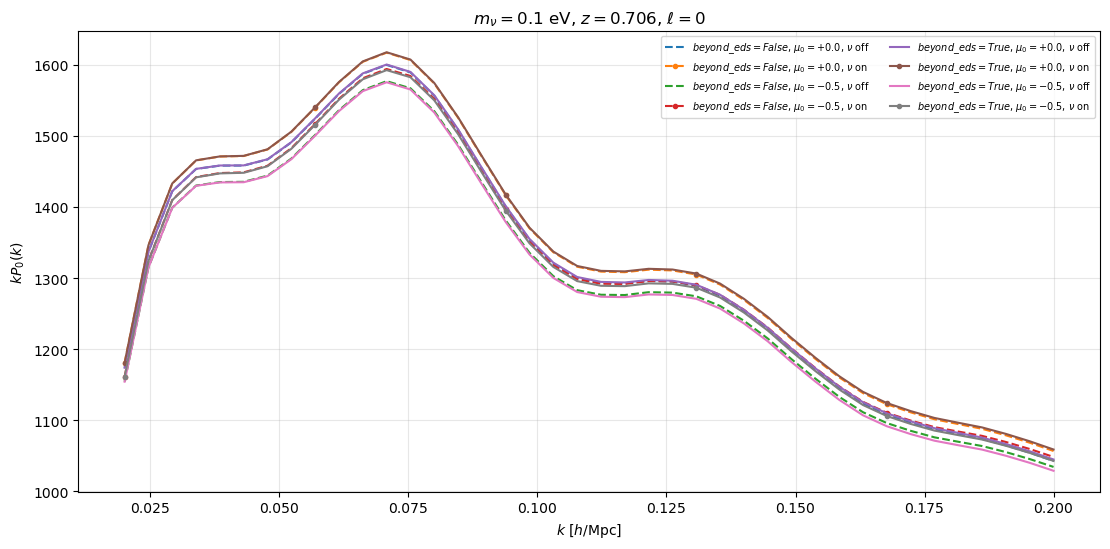

saved: /global/u2/c/crisjagq/FS_DR2/src/fkptjax_muMG/examples/test_neutrino_single_flag_legacy_projection_ell0.png


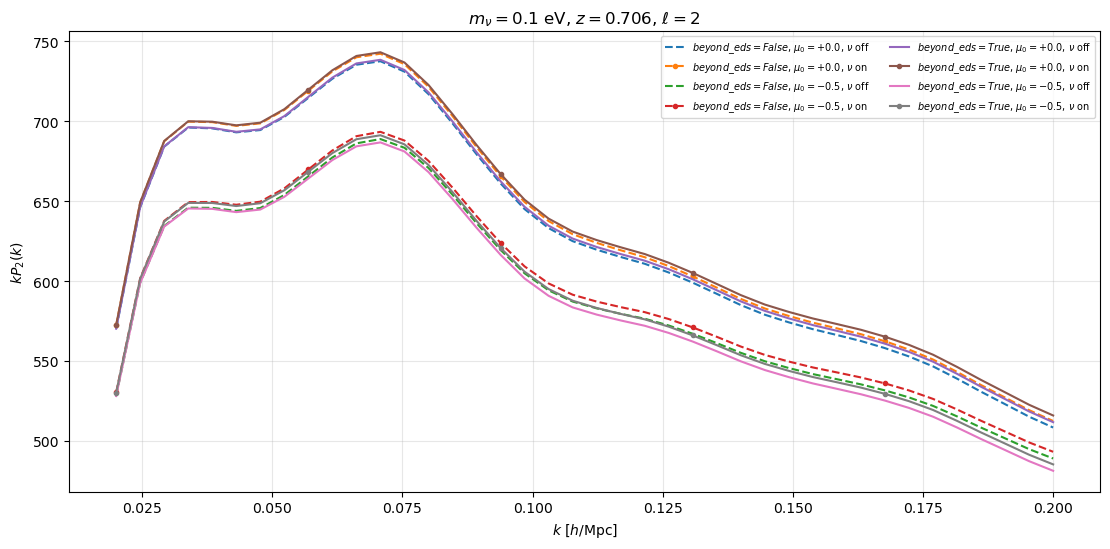

saved: /global/u2/c/crisjagq/FS_DR2/src/fkptjax_muMG/examples/test_neutrino_single_flag_legacy_projection_ell2.png


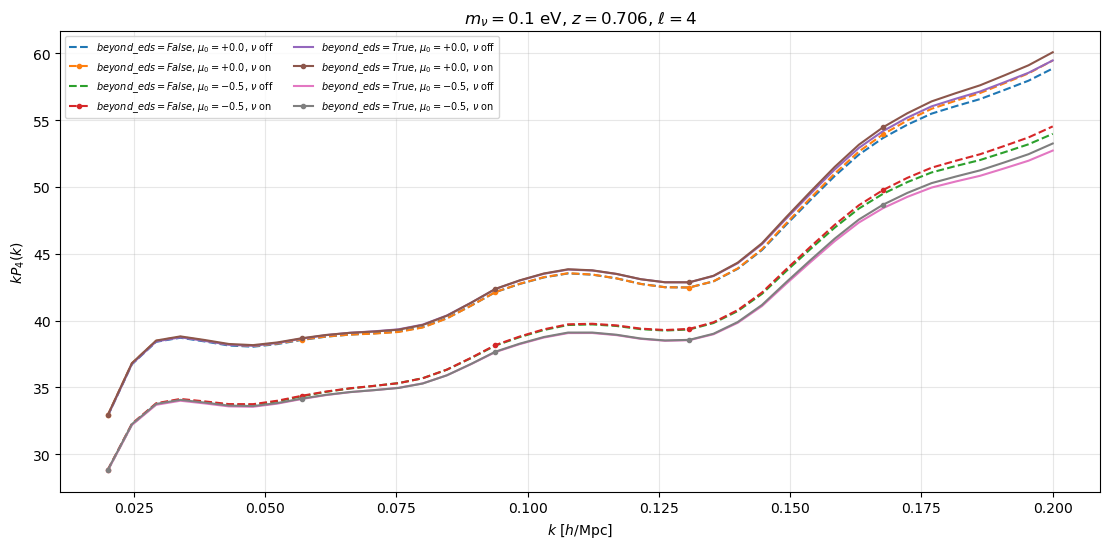

saved: /global/u2/c/crisjagq/FS_DR2/src/fkptjax_muMG/examples/test_neutrino_single_flag_legacy_projection_ell4.png


In [7]:
# One panel per multipole: all 8 permutations.
#
# dashed = beyond_eds=False
# solid  = beyond_eds=True
# marker = neutrino correction on

for iell, ell in enumerate(ELLS):
    fig, ax = plt.subplots(figsize=(11.2, 5.6))

    for beyond_eds in BEYOND_EDS:
        for mu0 in MU0_VALUES:
            for include_nu in INCLUDE_NEUTRINO_CORRECTIONS:
                poles = results[(bool(beyond_eds), float(mu0), bool(include_nu))]

                ax.plot(
                    np.asarray(k_eval),
                    np.asarray(k_eval) * poles[iell],
                    linestyle="-" if beyond_eds else "--",
                    marker="o" if include_nu else None,
                    markevery=8,
                    ms=3,
                    label=(
                        rf"$beyond\_eds={beyond_eds}$, "
                        rf"$\mu_0={mu0:+.1f}$, "
                        rf"$\nu$ {'on' if include_nu else 'off'}"
                    ),
                )

    ax.set_title(rf"$m_\nu={MNU}$ eV, $z={ZOUT}$, $\ell={ell}$")
    ax.set_xlabel(r"$k\ [h/{\rm Mpc}]$")
    ax.set_ylabel(rf"$kP_{{{ell}}}(k)$")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=7)
    fig.tight_layout()

    fn = Path.cwd() / f"test_neutrino_single_flag_legacy_projection_ell{ell}.png"
    fig.savefig(fn, dpi=180, bbox_inches="tight")
    plt.show()
    print("saved:", fn)


In [8]:
# Sanity check: does mu0=-0.5 reduce amplitudes?

for include_nu in INCLUDE_NEUTRINO_CORRECTIONS:
    for beyond_eds in BEYOND_EDS:
        key_gr = (bool(beyond_eds), 0.0, bool(include_nu))
        key_mg = (bool(beyond_eds), -0.5, bool(include_nu))
        if key_gr not in results or key_mg not in results:
            continue

        print(f"\ninclude_nu={include_nu}, beyond_eds={beyond_eds}")
        for iell, ell in enumerate(ELLS):
            ratio = results[key_mg][iell] / results[key_gr][iell]
            print(
                f"  ell={ell}: median P(mu0=-0.5)/P(mu0=0) = "
                f"{np.median(ratio):.5f}"
            )



include_nu=False, beyond_eds=False
  ell=0: median P(mu0=-0.5)/P(mu0=0) = 0.98667
  ell=2: median P(mu0=-0.5)/P(mu0=0) = 0.94015
  ell=4: median P(mu0=-0.5)/P(mu0=0) = 0.91279

include_nu=False, beyond_eds=True
  ell=0: median P(mu0=-0.5)/P(mu0=0) = 0.98403
  ell=2: median P(mu0=-0.5)/P(mu0=0) = 0.93160
  ell=4: median P(mu0=-0.5)/P(mu0=0) = 0.88929

include_nu=True, beyond_eds=False
  ell=0: median P(mu0=-0.5)/P(mu0=0) = 0.98679
  ell=2: median P(mu0=-0.5)/P(mu0=0) = 0.94047
  ell=4: median P(mu0=-0.5)/P(mu0=0) = 0.91368

include_nu=True, beyond_eds=True
  ell=0: median P(mu0=-0.5)/P(mu0=0) = 0.98411
  ell=2: median P(mu0=-0.5)/P(mu0=0) = 0.93178
  ell=4: median P(mu0=-0.5)/P(mu0=0) = 0.88953


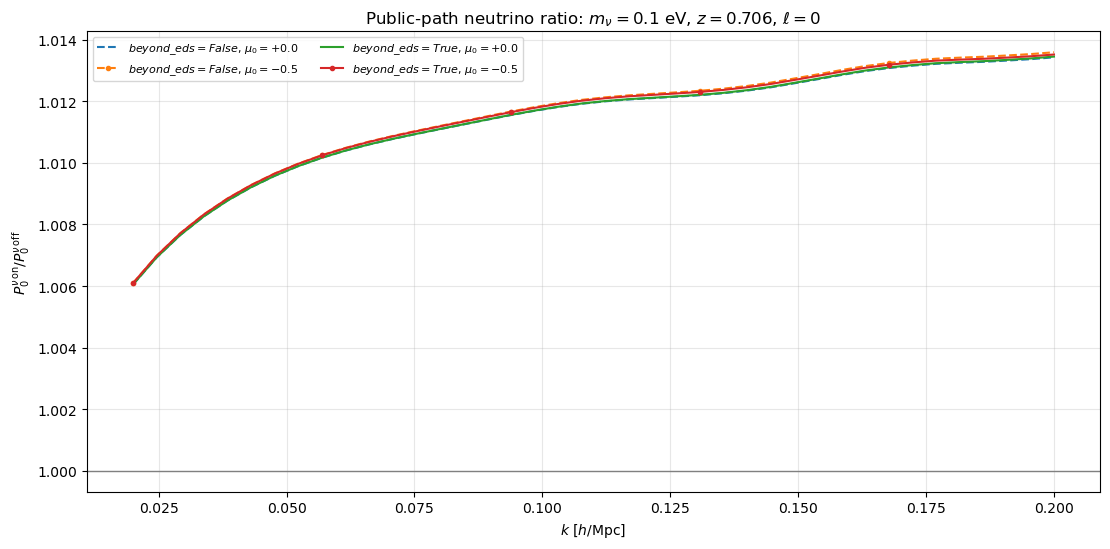

saved: /global/u2/c/crisjagq/FS_DR2/src/fkptjax_muMG/examples/test_neutrino_single_flag_legacy_projection_ell0_ratio.png


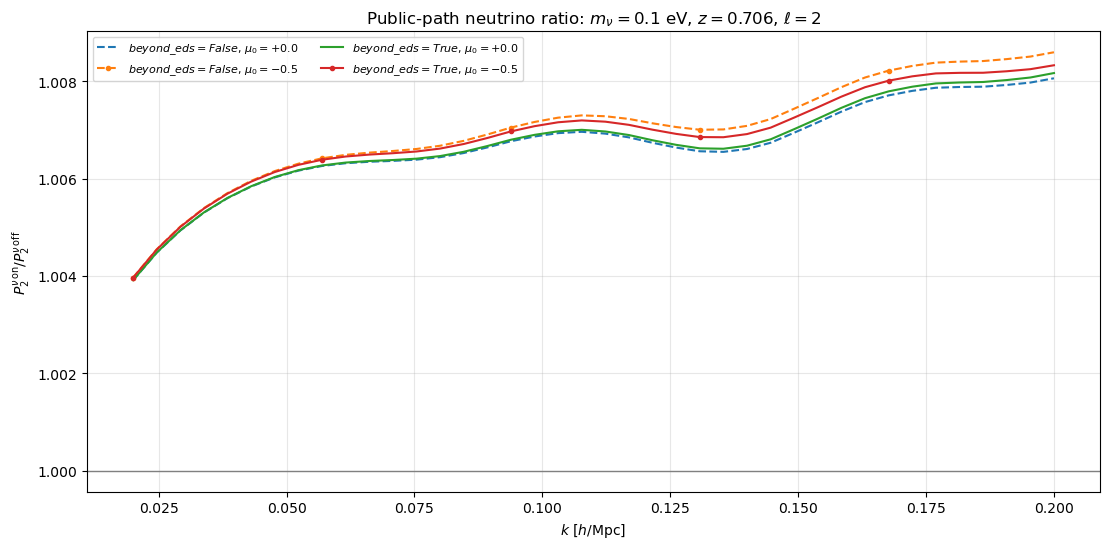

saved: /global/u2/c/crisjagq/FS_DR2/src/fkptjax_muMG/examples/test_neutrino_single_flag_legacy_projection_ell2_ratio.png


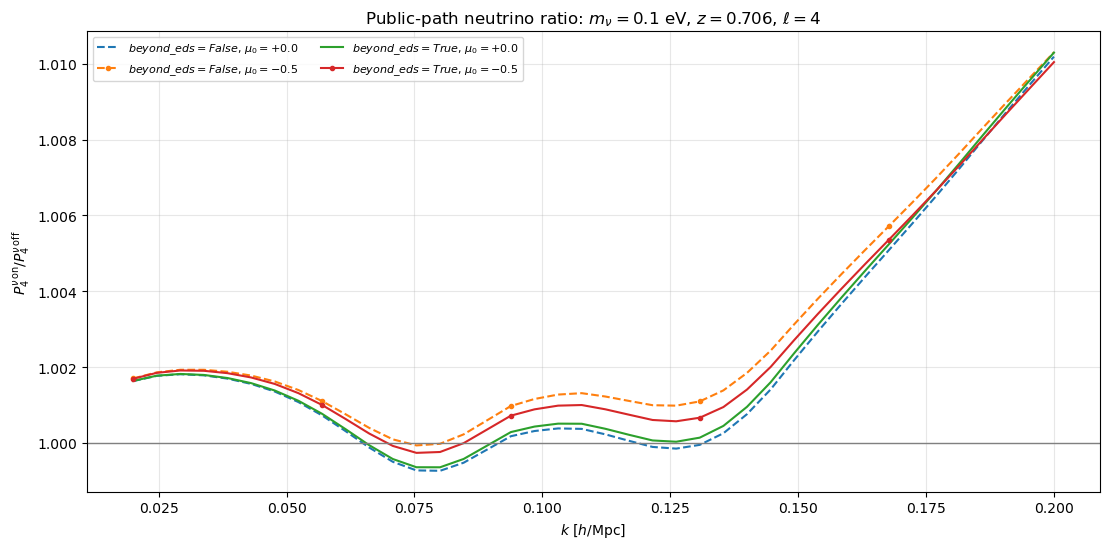

saved: /global/u2/c/crisjagq/FS_DR2/src/fkptjax_muMG/examples/test_neutrino_single_flag_legacy_projection_ell4_ratio.png


In [9]:
# Ratio: neutrino correction on / off at fixed mu0 and beyond_eds.
#
# Note: this ratio includes both changes made by the public path:
#   P_m -> P_cb
#   mu_nu = delta_tot / delta_cb

for iell, ell in enumerate(ELLS):
    fig, ax = plt.subplots(figsize=(11.2, 5.6))

    for beyond_eds in BEYOND_EDS:
        for mu0 in MU0_VALUES:
            p_off = results[(bool(beyond_eds), float(mu0), False)][iell]
            p_on = results[(bool(beyond_eds), float(mu0), True)][iell]

            ax.plot(
                np.asarray(k_eval),
                p_on / p_off,
                linestyle="-" if beyond_eds else "--",
                marker="o" if mu0 == -0.5 else None,
                markevery=8,
                ms=3,
                label=rf"$beyond\_eds={beyond_eds}$, $\mu_0={mu0:+.1f}$",
            )

    ax.axhline(1.0, color="0.5", lw=1)
    ax.set_title(
        rf"Public-path neutrino ratio: $m_\nu={MNU}$ eV, "
        rf"$z={ZOUT}$, $\ell={ell}$"
    )
    ax.set_xlabel(r"$k\ [h/{\rm Mpc}]$")
    ax.set_ylabel(
        rf"$P_{{{ell}}}^{{\nu\,\mathrm{{on}}}}/"
        rf"P_{{{ell}}}^{{\nu\,\mathrm{{off}}}}$"
    )
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()

    fn = Path.cwd() / f"test_neutrino_single_flag_legacy_projection_ell{ell}_ratio.png"
    fig.savefig(fn, dpi=180, bbox_inches="tight")
    plt.show()
    print("saved:", fn)